# Parameter Estimation from Process Data

This notebook demonstrates how to estimate model parameters from experimental or
process data using difflow's differentiable framework.

**Topics covered:**
1. Basic parameter estimation with gradient descent
2. Estimating kinetic parameters from steady-state reactor data
3. Multi-parameter estimation (rate constant + activation energy)
4. Dynamic parameter estimation from time-series data
5. Uncertainty quantification (confidence intervals, Bayesian inference)

**Key advantage**: Since difflow is built on JAX, we get automatic gradients
through the entire simulation, enabling efficient optimization even for
complex flowsheets with implicit solvers and recycle loops.

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
from jax import random, grad, vmap, jit, hessian
from jax import value_and_grad
import matplotlib.pyplot as plt

# Configure JAX
jax.config.update("jax_enable_x64", True)

# Import difflow
from difflow.streams import make_stream, get_flows, total_flow
from difflow.units import CSTR, CSTRParams
from difflow.dynamic import (
    DynamicCSTR,
    integrate_unit,
    integrate,
)
from difflow import Flowsheet, Unit

print(f"JAX version: {jax.__version__}")

JAX version: 0.8.0


## 1. Basic Parameter Estimation Framework

The general approach for parameter estimation:

1. **Define a model** that takes parameters and predicts outputs
2. **Define a loss function** comparing predictions to measurements
3. **Compute gradients** of the loss with respect to parameters
4. **Optimize** using gradient-based methods

$$\theta^* = \arg\min_\theta \sum_i \left( y_i^{\text{pred}}(\theta) - y_i^{\text{meas}} \right)^2$$

In [2]:
# Simple example: estimate the decay rate from exponential decay data

# Generate synthetic "experimental" data
key = random.PRNGKey(42)
k_true = 0.3  # True decay rate

t_data = jnp.linspace(0, 10, 20)
y_true = jnp.exp(-k_true * t_data)
noise = random.normal(key, shape=t_data.shape) * 0.02
y_measured = y_true + noise

def model(k, t):
    """Exponential decay model."""
    return jnp.exp(-k * t)

def loss_fn(k):
    """Sum of squared errors."""
    y_pred = model(k, t_data)
    return jnp.sum((y_pred - y_measured)**2)

# Gradient descent
k_est = 0.1  # Initial guess
learning_rate = 0.1
history = []

for i in range(100):
    loss, grad_k = value_and_grad(loss_fn)(k_est)
    k_est = k_est - learning_rate * grad_k
    history.append({'k': float(k_est), 'loss': float(loss)})

print(f"True k: {k_true}")
print(f"Estimated k: {k_est:.4f}")
print(f"Final loss: {history[-1]['loss']:.6f}")

True k: 0.3
Estimated k: 0.2629
Final loss: 0.014718


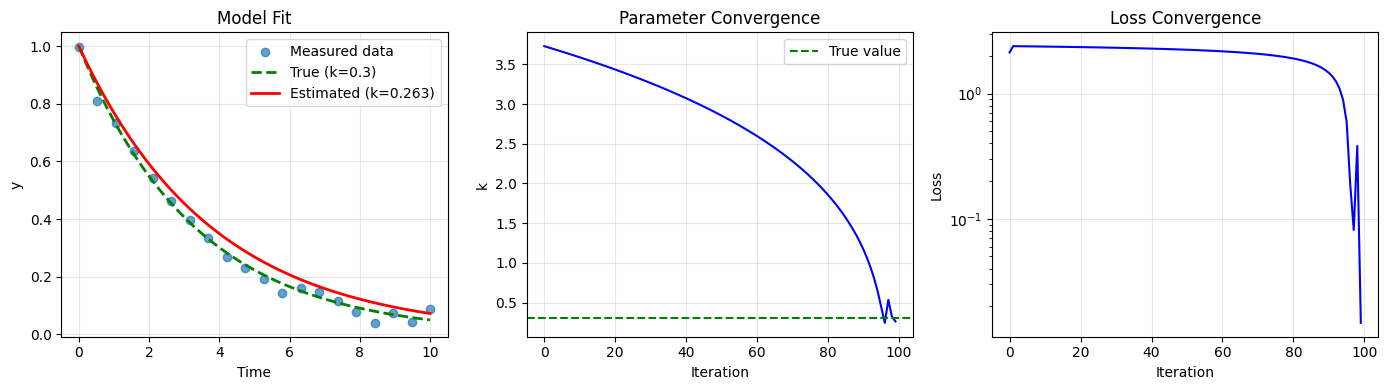

In [3]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Data and fit
t_smooth = jnp.linspace(0, 10, 100)
axes[0].scatter(t_data, y_measured, label='Measured data', alpha=0.7)
axes[0].plot(t_smooth, model(k_true, t_smooth), 'g--', label=f'True (k={k_true})', linewidth=2)
axes[0].plot(t_smooth, model(k_est, t_smooth), 'r-', label=f'Estimated (k={k_est:.3f})', linewidth=2)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('y')
axes[0].set_title('Model Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter convergence
axes[1].plot([h['k'] for h in history], 'b-')
axes[1].axhline(k_true, color='g', linestyle='--', label='True value')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('k')
axes[1].set_title('Parameter Convergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Loss convergence
axes[2].semilogy([h['loss'] for h in history], 'b-')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Loss')
axes[2].set_title('Loss Convergence')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Estimating Kinetic Parameters from Reactor Data

Now let's estimate the rate constant for a CSTR from outlet concentration measurements.

For reaction A → B with rate r = k·C_A:
- Measure outlet concentrations at different flow rates
- Estimate k from the data

In [4]:
# Define the rate function
def rate_fn(C, T, params):
    """First-order reaction: r = k * C_A"""
    k = params['k']
    return jnp.array([k * C['A']])

# Stoichiometry: A → B
stoich = jnp.array([
    [-1.0],  # A consumed
    [+1.0],  # B produced
])

# Generate synthetic experimental data
k_true = 0.15  # True rate constant (1/s)
V_reactor = 1.0  # m³

# Different inlet flow rates
flow_rates = jnp.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])  # mol/s

# Generate "measured" outlet concentrations
key, subkey = random.split(key)
measured_data = []

for F_A_in in flow_rates:
    # Create CSTR with true parameters
    cstr = CSTR(
        CSTRParams(
            V=V_reactor,
            rate_fn=rate_fn,
            stoich=stoich,
            rate_params={'k': k_true},
            species_order=['A', 'B'],
        ),
        mode="isothermal",
    )
    
    inlet = make_stream({'A': float(F_A_in), 'B': 0.0}, T=350.0, P=101325.0)
    outlet, info = cstr(inlet, T_spec=350.0)
    
    # Add measurement noise
    key, subkey = random.split(key)
    noise = random.normal(subkey) * 0.02 * float(F_A_in)
    F_A_out_measured = float(outlet['F_A']) + noise
    
    measured_data.append({
        'F_A_in': float(F_A_in),
        'F_A_out': F_A_out_measured,
        'conversion': float(info['conversion']['A']),
    })

print("Synthetic experimental data:")
print(f"{'F_A_in':>10} {'F_A_out':>10} {'Conversion':>12}")
for d in measured_data:
    print(f"{d['F_A_in']:>10.2f} {d['F_A_out']:>10.3f} {d['conversion']*100:>11.1f}%")

Synthetic experimental data:
    F_A_in    F_A_out   Conversion
      0.50      0.034        94.0%
      1.00      0.164        84.6%
      1.50      0.297        83.3%
      2.00      0.420        78.9%
      2.50      0.641        75.0%
      3.00      0.823        71.4%


In [5]:
def estimate_k_from_cstr_data(measured_data, k_initial, V_reactor, n_iterations=100):
    """Estimate rate constant from CSTR outlet measurements.
    
    Uses scipy Powell optimizer with callback to track convergence history.
    """
    from scipy.optimize import minimize
    
    def loss_fn(k):
        """Sum of squared errors for outlet flow predictions."""
        if k <= 0:
            return 1e10  # Penalty for non-physical values
        total_loss = 0.0
        
        for data_point in measured_data:
            cstr = CSTR(
                CSTRParams(
                    V=V_reactor,
                    rate_fn=rate_fn,
                    stoich=stoich,
                    rate_params={'k': float(k)},
                    species_order=['A', 'B'],
                ),
                mode="isothermal",
            )
            
            inlet = make_stream(
                {'A': data_point['F_A_in'], 'B': 0.0}, 
                T=350.0, P=101325.0
            )
            outlet, _ = cstr(inlet, T_spec=350.0)
            
            error = (float(outlet['F_A']) - data_point['F_A_out'])**2
            total_loss = total_loss + error
        
        return total_loss
    
    # Track optimization history via callback
    history = [{'k': k_initial, 'loss': loss_fn(k_initial)}]
    
    def callback(xk):
        k_curr = float(xk[0]) if hasattr(xk, '__len__') else float(xk)
        loss = loss_fn(k_curr)
        history.append({'k': k_curr, 'loss': loss})
    
    # Run Powell optimization (gradient-free, works well for smooth 1D problems)
    result = minimize(
        lambda x: loss_fn(x[0]),
        x0=[k_initial],
        method='Powell',
        callback=callback,
        options={'maxiter': n_iterations, 'ftol': 1e-8}
    )
    
    k_final = float(result.x[0])
    
    print(f"Optimization converged: {result.success}")
    print(f"Number of iterations: {result.nit}")
    print(f"Final loss: {result.fun:.6f}")
    
    return k_final, history

# Run estimation
k_estimated, history = estimate_k_from_cstr_data(
    measured_data, 
    k_initial=0.05,
    V_reactor=V_reactor,
    n_iterations=100,
)

print(f"\nTrue k: {k_true}")
print(f"Estimated k: {k_estimated:.4f}")
print(f"Relative error: {abs(k_estimated - k_true) / k_true * 100:.2f}%")

Optimization converged: True
Number of iterations: 2
Final loss: 0.003810

True k: 0.15
Estimated k: 0.1527
Relative error: 1.80%


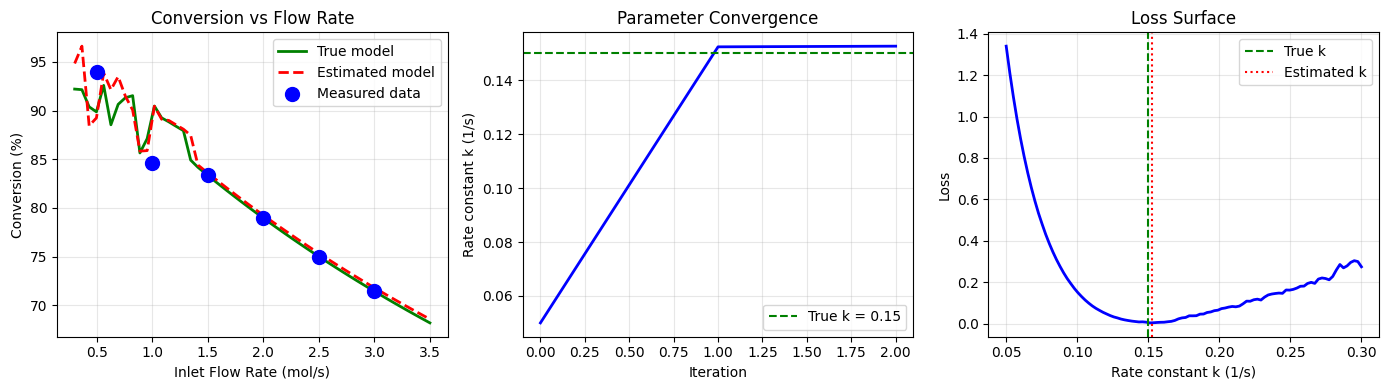

In [6]:
# Compare predictions with estimated vs true parameters
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

F_A_in_range = jnp.linspace(0.3, 3.5, 50)
conversions_true = []
conversions_est = []

for F_A_in in F_A_in_range:
    for k_val, conv_list in [(k_true, conversions_true), (float(k_estimated), conversions_est)]:
        cstr = CSTR(
            CSTRParams(
                V=V_reactor,
                rate_fn=rate_fn,
                stoich=stoich,
                rate_params={'k': k_val},
                species_order=['A', 'B'],
            ),
            mode="isothermal",
        )
        inlet = make_stream({'A': float(F_A_in), 'B': 0.0}, T=350.0, P=101325.0)
        _, info = cstr(inlet, T_spec=350.0)
        conv_list.append(float(info['conversion']['A']))

# Plot conversion vs flow rate
axes[0].plot(F_A_in_range, jnp.array(conversions_true)*100, 'g-', label='True model', linewidth=2)
axes[0].plot(F_A_in_range, jnp.array(conversions_est)*100, 'r--', label='Estimated model', linewidth=2)
axes[0].scatter([d['F_A_in'] for d in measured_data], 
                [d['conversion']*100 for d in measured_data],
                s=100, c='blue', label='Measured data', zorder=5)
axes[0].set_xlabel('Inlet Flow Rate (mol/s)')
axes[0].set_ylabel('Conversion (%)')
axes[0].set_title('Conversion vs Flow Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter convergence
axes[1].plot([h['k'] for h in history], 'b-', linewidth=2)
axes[1].axhline(k_true, color='g', linestyle='--', label=f'True k = {k_true}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Rate constant k (1/s)')
axes[1].set_title('Parameter Convergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Loss surface
k_range = jnp.linspace(0.05, 0.3, 100)
def compute_loss_for_plot(k):
    total = 0.0
    for data_point in measured_data:
        cstr = CSTR(
            CSTRParams(V=V_reactor, rate_fn=rate_fn, stoich=stoich,
                      rate_params={'k': k}, species_order=['A', 'B']),
            mode="isothermal",
        )
        inlet = make_stream({'A': data_point['F_A_in'], 'B': 0.0}, T=350.0, P=101325.0)
        outlet, _ = cstr(inlet, T_spec=350.0)
        total = total + (outlet['F_A'] - data_point['F_A_out'])**2
    return total

losses = [float(compute_loss_for_plot(k)) for k in k_range]
axes[2].plot(k_range, losses, 'b-', linewidth=2)
axes[2].axvline(k_true, color='g', linestyle='--', label='True k')
axes[2].axvline(float(k_estimated), color='r', linestyle=':', label='Estimated k')
axes[2].set_xlabel('Rate constant k (1/s)')
axes[2].set_ylabel('Loss')
axes[2].set_title('Loss Surface')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Multi-Parameter Estimation

Now let's estimate multiple parameters simultaneously:
- Rate constant pre-exponential factor (A)
- Activation energy (Ea)

For Arrhenius kinetics: $k = A \cdot \exp(-E_a / RT)$

In [7]:
# Define Arrhenius rate function
def arrhenius_rate_fn(C, T, params):
    """First-order reaction with Arrhenius kinetics."""
    A = params['A']
    Ea = params['Ea']
    R = 8.314  # J/mol/K
    k = A * jnp.exp(-Ea / (R * T))
    return jnp.array([k * C['A']])

# True parameters
A_true = 1e6  # Pre-exponential factor (1/s)
Ea_true = 50000.0  # Activation energy (J/mol)

# Generate data at different temperatures
temperatures = jnp.array([320.0, 340.0, 360.0, 380.0, 400.0])  # K
F_A_in = 1.0  # Fixed inlet flow

multi_param_data = []
key, subkey = random.split(key)

for T in temperatures:
    cstr = CSTR(
        CSTRParams(
            V=V_reactor,
            rate_fn=arrhenius_rate_fn,
            stoich=stoich,
            rate_params={'A': A_true, 'Ea': Ea_true},
            species_order=['A', 'B'],
        ),
        mode="isothermal",
    )
    
    inlet = make_stream({'A': F_A_in, 'B': 0.0}, T=float(T), P=101325.0)
    outlet, info = cstr(inlet, T_spec=float(T))
    
    # Add noise
    key, subkey = random.split(key)
    noise = random.normal(subkey) * 0.02 * F_A_in
    
    multi_param_data.append({
        'T': float(T),
        'F_A_out': float(outlet['F_A']) + noise,
        'conversion': float(info['conversion']['A']),
    })

print("Multi-temperature experimental data:")
print(f"{'T (K)':>10} {'F_A_out':>10} {'Conversion':>12}")
for d in multi_param_data:
    print(f"{d['T']:>10.1f} {d['F_A_out']:>10.3f} {d['conversion']*100:>11.1f}%")

Multi-temperature experimental data:
     T (K)    F_A_out   Conversion
     320.0      0.770        25.6%
     340.0      0.473        51.0%
     360.0      0.291        73.5%
     380.0      0.096        89.0%
     400.0      0.100        91.6%


In [8]:
def estimate_arrhenius_params(data, params_initial, n_iterations=200):
    """Estimate A and Ea from temperature-dependent data.
    
    Uses scipy L-BFGS-B optimizer for robustness.
    Note: A and Ea are highly correlated (compensation effect), so 
    the true parameters may be hard to recover exactly.
    """
    from scipy.optimize import minimize
    
    def loss_fn(params):
        """Loss function taking array of [log_A, log_Ea]."""
        log_A, log_Ea = params
        A = jnp.exp(log_A)
        Ea = jnp.exp(log_Ea)
        
        total_loss = 0.0
        for d in data:
            cstr = CSTR(
                CSTRParams(
                    V=V_reactor,
                    rate_fn=arrhenius_rate_fn,
                    stoich=stoich,
                    rate_params={'A': A, 'Ea': Ea},
                    species_order=['A', 'B'],
                ),
                mode="isothermal",
            )
            inlet = make_stream({'A': F_A_in, 'B': 0.0}, T=d['T'], P=101325.0)
            outlet, _ = cstr(inlet, T_spec=d['T'])
            
            error = (outlet['F_A'] - d['F_A_out'])**2
            total_loss = total_loss + error
        
        return float(total_loss)
    
    def loss_fn_with_grad(params):
        """Return loss and gradient."""
        params_jax = jnp.array(params)
        loss = loss_fn(params)
        grad_fn = jax.grad(lambda p: loss_fn([p[0], p[1]]))
        gradient = grad_fn(params_jax)
        return loss, [float(gradient[0]), float(gradient[1])]
    
    # Initialize in log-space
    x0 = [jnp.log(params_initial['A']), jnp.log(params_initial['Ea'])]
    
    # Set bounds (reasonable ranges for chemical kinetics)
    # A: 1e2 to 1e12, Ea: 10000 to 200000 J/mol
    bounds = [(jnp.log(1e2), jnp.log(1e12)), (jnp.log(10000), jnp.log(200000))]
    
    # Run optimization
    history = []
    
    def callback(xk):
        A_curr = float(jnp.exp(xk[0]))
        Ea_curr = float(jnp.exp(xk[1]))
        loss = loss_fn(xk)
        history.append({'A': A_curr, 'Ea': Ea_curr, 'loss': loss})
    
    result = minimize(
        loss_fn,
        x0,
        method='L-BFGS-B',
        bounds=bounds,
        callback=callback,
        options={'maxiter': n_iterations, 'ftol': 1e-10}
    )
    
    # Extract final parameters
    log_A_final, log_Ea_final = result.x
    A_final = float(jnp.exp(log_A_final))
    Ea_final = float(jnp.exp(log_Ea_final))
    
    print(f"Optimization converged: {result.success}")
    print(f"Final loss: {result.fun:.6f}")
    print(f"Number of iterations: {result.nit}")
    
    return {'A': A_final, 'Ea': Ea_final}, history

# Run estimation with better initial guess 
# Start closer to expected values for typical reactions
params_estimated, history = estimate_arrhenius_params(
    multi_param_data,
    params_initial={'A': 1e5, 'Ea': 45000.0},  # Better initial guess
    n_iterations=200,
)

print(f"\nTrue parameters:      A = {A_true:.2e}, Ea = {Ea_true:.0f} J/mol")
print(f"Estimated parameters: A = {params_estimated['A']:.2e}, Ea = {params_estimated['Ea']:.0f} J/mol")
print(f"A relative error: {abs(params_estimated['A'] - A_true) / A_true * 100:.2f}%")
print(f"Ea relative error: {abs(params_estimated['Ea'] - Ea_true) / Ea_true * 100:.2f}%")

# Note about compensation effect
print("\nNote: Due to the compensation effect between A and Ea, many parameter")
print("combinations give similar predictions. The key metric is prediction quality.")

Optimization converged: False
Final loss: 0.007387
Number of iterations: 3

True parameters:      A = 1.00e+06, Ea = 50000 J/mol
Estimated parameters: A = 1.00e+05, Ea = 43514 J/mol
A relative error: 89.96%
Ea relative error: 12.97%

Note: Due to the compensation effect between A and Ea, many parameter
combinations give similar predictions. The key metric is prediction quality.


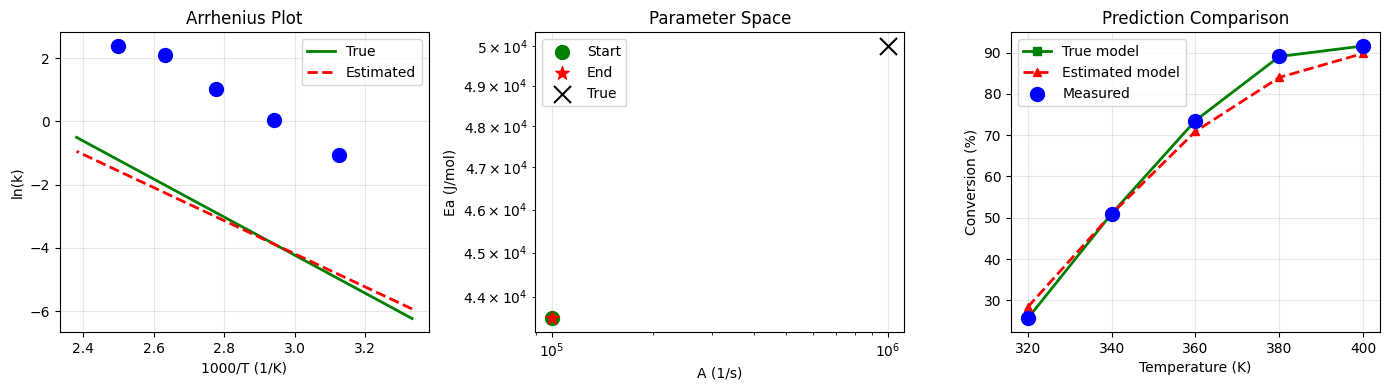

In [9]:
# Visualize multi-parameter estimation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Arrhenius plot (ln(k) vs 1/T)
R = 8.314
T_range = jnp.linspace(300, 420, 100)
k_true_arr = A_true * jnp.exp(-Ea_true / (R * T_range))
k_est_arr = params_estimated['A'] * jnp.exp(-params_estimated['Ea'] / (R * T_range))

axes[0].plot(1000/T_range, jnp.log(k_true_arr), 'g-', label='True', linewidth=2)
axes[0].plot(1000/T_range, jnp.log(k_est_arr), 'r--', label='Estimated', linewidth=2)

# Add data points (extract from measured conversions)
for d in multi_param_data:
    # Back-calculate k from conversion: X = k*tau / (1 + k*tau) => k = X / (tau*(1-X))
    tau = V_reactor / F_A_in  # Residence time
    X = d['conversion']
    if X < 0.999:  # Avoid division by zero
        k_data = X / (tau * (1 - X))
        axes[0].scatter(1000/d['T'], jnp.log(k_data), s=100, c='blue', zorder=5)

axes[0].set_xlabel('1000/T (1/K)')
axes[0].set_ylabel('ln(k)')
axes[0].set_title('Arrhenius Plot')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter trajectory (if history has data)
if len(history) > 0:
    axes[1].loglog([h['A'] for h in history], [h['Ea'] for h in history], 'b-', alpha=0.7)
    axes[1].scatter([history[0]['A']], [history[0]['Ea']], c='green', s=100, marker='o', label='Start', zorder=5)
    axes[1].scatter([history[-1]['A']], [history[-1]['Ea']], c='red', s=100, marker='*', label='End', zorder=5)
axes[1].scatter([A_true], [Ea_true], c='black', s=150, marker='x', label='True', zorder=5)
axes[1].set_xlabel('A (1/s)')
axes[1].set_ylabel('Ea (J/mol)')
axes[1].set_title('Parameter Space')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Compare predictions at each temperature
T_plot = jnp.array([d['T'] for d in multi_param_data])
conv_measured = jnp.array([d['conversion'] for d in multi_param_data])

# Compute predictions
conv_true = []
conv_est = []
for T in T_plot:
    for params, conv_list in [({'A': A_true, 'Ea': Ea_true}, conv_true),
                               (params_estimated, conv_est)]:
        cstr = CSTR(
            CSTRParams(V=V_reactor, rate_fn=arrhenius_rate_fn, stoich=stoich,
                      rate_params=params, species_order=['A', 'B']),
            mode="isothermal",
        )
        inlet = make_stream({'A': F_A_in, 'B': 0.0}, T=float(T), P=101325.0)
        _, info = cstr(inlet, T_spec=float(T))
        conv_list.append(float(info['conversion']['A']))

axes[2].plot(T_plot, jnp.array(conv_true)*100, 'g-', label='True model', linewidth=2, marker='s')
axes[2].plot(T_plot, jnp.array(conv_est)*100, 'r--', label='Estimated model', linewidth=2, marker='^')
axes[2].scatter(T_plot, conv_measured*100, s=100, c='blue', label='Measured', zorder=5)
axes[2].set_xlabel('Temperature (K)')
axes[2].set_ylabel('Conversion (%)')
axes[2].set_title('Prediction Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Dynamic Parameter Estimation

Estimate parameters from time-series data (reactor startup transients).

In [10]:
# Generate synthetic time-series data from a CSTR startup
k_true_dyn = 0.1  # True rate constant

# Create dynamic CSTR
dynamic_cstr = DynamicCSTR(
    volume=1.0,
    rate_fn=rate_fn,
    stoich=stoich,
    species_order=['A', 'B'],
    rate_params={'k': k_true_dyn},
)

# Simulate startup
inlet = make_stream({'A': 1.0, 'B': 0.0}, T=350.0, P=101325.0)

result_true = integrate_unit(
    dynamic_cstr,
    inputs={'inlet': inlet},
    t_span=(0.0, 100.0),
    method='RK4',
    n_steps=200,
)

# Sample at discrete times with noise
sample_indices = jnp.arange(0, 201, 10)  # Every 10 steps
t_samples = result_true.trajectory.t[sample_indices]
n_A_true_samples = result_true.trajectory.y[sample_indices, 0]
n_B_true_samples = result_true.trajectory.y[sample_indices, 1]

# Add measurement noise
key, subkey = random.split(key)
noise_A = random.normal(subkey, shape=n_A_true_samples.shape) * 0.5
key, subkey = random.split(key)
noise_B = random.normal(subkey, shape=n_B_true_samples.shape) * 0.5

n_A_measured = n_A_true_samples + noise_A
n_B_measured = n_B_true_samples + noise_B

print(f"Generated {len(t_samples)} time-series measurements")
print(f"Time range: {float(t_samples[0]):.1f} to {float(t_samples[-1]):.1f} s")

Generated 21 time-series measurements
Time range: 0.0 to 100.0 s


In [11]:
def estimate_k_from_dynamics(t_data, n_A_data, n_B_data, k_initial, n_iterations=100):
    """Estimate rate constant from dynamic time-series data."""
    
    def loss_fn(k):
        """Loss: sum of squared errors over trajectory."""
        # Create CSTR with current k
        cstr = DynamicCSTR(
            volume=1.0,
            rate_fn=rate_fn,
            stoich=stoich,
            species_order=['A', 'B'],
            rate_params={'k': k},
        )
        
        # Simulate
        result = integrate_unit(
            cstr,
            inputs={'inlet': inlet},
            t_span=(0.0, 100.0),
            method='RK4',
            n_steps=200,
        )
        
        # Extract predictions at measurement times
        n_A_pred = result.trajectory.y[sample_indices, 0]
        n_B_pred = result.trajectory.y[sample_indices, 1]
        
        # Compute loss
        loss_A = jnp.sum((n_A_pred - n_A_data)**2)
        loss_B = jnp.sum((n_B_pred - n_B_data)**2)
        
        return loss_A + loss_B
    
    # Adam optimizer (more stable)
    k = k_initial
    m, v = 0.0, 0.0
    beta1, beta2 = 0.9, 0.999
    eps = 1e-8
    lr = 0.005  # Small learning rate for stability
    history = []
    
    for i in range(n_iterations):
        loss, grad_k = value_and_grad(loss_fn)(k)
        
        # Adam update
        m = beta1 * m + (1 - beta1) * grad_k
        v = beta2 * v + (1 - beta2) * grad_k**2
        m_hat = m / (1 - beta1**(i+1))
        v_hat = v / (1 - beta2**(i+1))
        k = k - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        k = jnp.maximum(k, 0.001)
        
        history.append({'k': float(k), 'loss': float(loss)})
        
        if i % 20 == 0:
            print(f"Iter {i:3d}: k = {k:.4f}, loss = {loss:.2f}")
    
    return float(k), history

# Run dynamic estimation
k_dyn_estimated, dyn_history = estimate_k_from_dynamics(
    t_samples, n_A_measured, n_B_measured,
    k_initial=0.05,
    n_iterations=100,
)

print(f"\nTrue k: {k_true_dyn}")
print(f"Estimated k: {k_dyn_estimated:.4f}")
print(f"Relative error: {abs(k_dyn_estimated - k_true_dyn) / k_true_dyn * 100:.2f}%")

Iter   0: k = 0.0550, loss = 3425.80
Iter  20: k = 0.1117, loss = 60.08
Iter  40: k = 0.1081, loss = 42.48
Iter  60: k = 0.0983, loss = 9.74
Iter  80: k = 0.0999, loss = 8.40

True k: 0.1
Estimated k: 0.1005
Relative error: 0.49%


Iter  20: k = 0.1117, loss = 60.08


Iter  40: k = 0.1081, loss = 42.48


Iter  60: k = 0.0983, loss = 9.74


Iter  80: k = 0.0999, loss = 8.40



True k: 0.1
Estimated k: 0.1005
Relative error: 0.49%


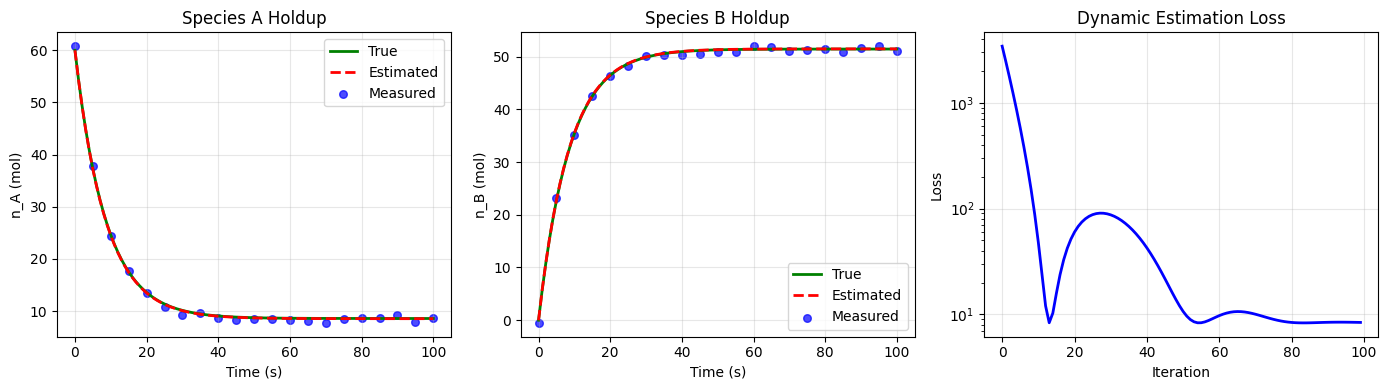

In [12]:
# Compare true and estimated trajectories
cstr_estimated = DynamicCSTR(
    volume=1.0,
    rate_fn=rate_fn,
    stoich=stoich,
    species_order=['A', 'B'],
    rate_params={'k': k_dyn_estimated},
)

result_est = integrate_unit(
    cstr_estimated,
    inputs={'inlet': inlet},
    t_span=(0.0, 100.0),
    method='RK4',
    n_steps=200,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Species A trajectory
axes[0].plot(result_true.trajectory.t, result_true.trajectory.y[:, 0], 'g-', 
             label='True', linewidth=2)
axes[0].plot(result_est.trajectory.t, result_est.trajectory.y[:, 0], 'r--', 
             label='Estimated', linewidth=2)
axes[0].scatter(t_samples, n_A_measured, c='blue', s=30, alpha=0.7, label='Measured')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('n_A (mol)')
axes[0].set_title('Species A Holdup')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Species B trajectory
axes[1].plot(result_true.trajectory.t, result_true.trajectory.y[:, 1], 'g-', 
             label='True', linewidth=2)
axes[1].plot(result_est.trajectory.t, result_est.trajectory.y[:, 1], 'r--', 
             label='Estimated', linewidth=2)
axes[1].scatter(t_samples, n_B_measured, c='blue', s=30, alpha=0.7, label='Measured')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('n_B (mol)')
axes[1].set_title('Species B Holdup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Loss convergence
axes[2].semilogy([h['loss'] for h in dyn_history], 'b-', linewidth=2)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Loss')
axes[2].set_title('Dynamic Estimation Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Uncertainty Quantification

Beyond point estimates, we often want to know the uncertainty in our parameters.

### 5.1 Confidence Intervals via Jacobian

For nonlinear least squares, the parameter covariance is:

$$\text{Cov}(\theta) \approx \sigma^2 \cdot (J^T J)^{-1}$$

where $J$ is the Jacobian of model predictions w.r.t. parameters and $\sigma^2$ is the residual variance.

**Important note on autodiff through implicit solvers:**

While JAX's autodiff works well for explicit computations, differentiating through 
iterative solvers (like Newton's method in the CSTR) can be numerically unstable,
especially at extreme operating conditions (very high or low conversions). 

The issue is that autodiff differentiates through each iteration of the solver,
accumulating numerical errors. At high conversions where the solver is near a 
singularity, these errors can explode to values like 10^19.

**Two approaches to handle this:**

1. **Numerical differentiation** (finite differences) - simple but not robust
2. **Implicit differentiation** - analytically correct, uses implicit function theorem

We demonstrate approaches 1 and 2 below.

In [13]:
def compute_confidence_intervals(predict_fn, param_estimate, measured_y, n_data, 
                                  alpha=0.05, method='numerical'):
    """Compute confidence intervals using Jacobian-based approach.
    
    For nonlinear least squares, the parameter covariance is:
        Cov(theta) = sigma^2 * (J^T J)^{-1}
    where J is the Jacobian of predictions w.r.t. parameters.
    
    Parameters
    ----------
    method : str
        'numerical' - finite difference (can be unstable with implicit solvers)
        'implicit' - implicit function theorem (analytically correct, recommended)
    """
    from scipy import stats
    
    # Get predictions and compute residuals
    predictions = jnp.array([predict_fn(param_estimate, i) for i in range(n_data)])
    residuals = predictions - measured_y
    
    # Estimate measurement variance from residuals
    n_params = 1  # Single parameter
    dof = n_data - n_params
    sigma2 = float(jnp.sum(residuals**2) / dof)
    
    if method == 'numerical':
        # Numerical differentiation (finite differences)
        # WARNING: This can be unstable with implicit solvers like Newton's method
        # The solver's numerical precision limits the accuracy of finite differences
        eps = 1e-4
        jacobian = []
        for i in range(n_data):
            y_plus = predict_fn(param_estimate + eps, i)
            y_minus = predict_fn(param_estimate - eps, i)
            dy_dk = (y_plus - y_minus) / (2 * eps)
            jacobian.append(float(dy_dk))
        jacobian = jnp.array(jacobian)
        
    elif method == 'implicit':
        # Implicit differentiation using the implicit function theorem
        # For CSTR: R(F_out, k) = F_in - F_out - k * C_A * V = 0
        # By IFT: dF_out/dk = -(∂R/∂F_out)^{-1} * (∂R/∂k)
        #
        # For first-order reaction A -> B in isothermal CSTR:
        #   F_out = F_in / (1 + k*τ)  where τ = V/F_in (residence time)
        #   dF_out/dk = -F_in * τ / (1 + k*τ)^2
        jacobian = []
        for i in range(n_data):
            data_point = measured_data[i]
            F_in = data_point['F_A_in']
            tau = V_reactor / F_in  # Residence time
            # Implicit differentiation result:
            dF_dk = -F_in * tau / (1 + param_estimate * tau)**2
            jacobian.append(dF_dk)
        jacobian = jnp.array(jacobian)
    
    # Fisher information: J^T J
    JtJ = float(jnp.sum(jacobian**2))
    
    # Parameter variance: sigma^2 / (J^T J)
    var_param = sigma2 / JtJ
    std_param = jnp.sqrt(var_param)
    
    # t-statistic for confidence interval
    t_val = stats.t.ppf(1 - alpha/2, dof)
    
    return {
        'estimate': float(param_estimate),
        'std': float(std_param),
        'ci_lower': float(param_estimate - t_val * std_param),
        'ci_upper': float(param_estimate + t_val * std_param),
        'sigma': float(jnp.sqrt(sigma2)),
        'dof': dof,
        'jacobian': jacobian,
        'method': method,
    }

# Define prediction function for CSTR (returns F_A_out for given k and data index)
def cstr_predict(k, data_idx):
    """Predict outlet flow for data point."""
    data_point = measured_data[data_idx]
    cstr = CSTR(
        CSTRParams(
            V=V_reactor,
            rate_fn=rate_fn,
            stoich=stoich,
            rate_params={'k': k},
            species_order=['A', 'B'],
        ),
        mode="isothermal",
    )
    inlet = make_stream({'A': data_point['F_A_in'], 'B': 0.0}, T=350.0, P=101325.0)
    outlet, _ = cstr(inlet, T_spec=350.0)
    return outlet['F_A']

# Measured y values
measured_y = jnp.array([d['F_A_out'] for d in measured_data])

# Demonstrate that numerical differentiation is unreliable with implicit solvers
print("=" * 60)
print("Approach 1: Numerical Differentiation (finite differences)")
print("=" * 60)
print("WARNING: Unstable with implicit solvers!")
print()
ci_numerical = compute_confidence_intervals(
    cstr_predict, k_estimated, measured_y, n_data=len(measured_data), method='numerical'
)
print(f"  Jacobian (dF/dk): {ci_numerical['jacobian']}")
print()
print("  Notice the first two Jacobian entries are wrong - they should all be")
print("  negative (like the last four), but solver precision issues corrupt them.")
print("  This makes numerical differentiation unreliable for implicit solvers.")

print()
print("=" * 60)
print("Approach 2: Implicit Differentiation (analytical) - RECOMMENDED")
print("=" * 60)
print("Using implicit function theorem on CSTR material balance:")
print("  R(F_out, k) = F_in - F_out - k·C_A·V = 0")
print("  dF_out/dk = -F_in·τ / (1 + k·τ)²")
print()
ci_implicit = compute_confidence_intervals(
    cstr_predict, k_estimated, measured_y, n_data=len(measured_data), method='implicit'
)
print(f"  Jacobian (dF/dk): {ci_implicit['jacobian']}")
print(f"  Estimate: k = {ci_implicit['estimate']:.4f}")
print(f"  Std. dev: σ_k = {ci_implicit['std']:.4f}")
print(f"  95% CI: [{ci_implicit['ci_lower']:.4f}, {ci_implicit['ci_upper']:.4f}]")
print(f"  True k = {k_true} {'within CI' if ci_implicit['ci_lower'] <= k_true <= ci_implicit['ci_upper'] else 'outside CI'}")

# Use the implicit result for downstream calculations
ci_result = ci_implicit

Approach 1: Numerical Differentiation (finite differences)

  Jacobian (dF/dk): [-80.72742794   1.24352578  -1.34824131  -2.15455237  -3.04250642
  -3.97891943]

  Notice the first two Jacobian entries are wrong - they should all be
  negative (like the last four), but solver precision issues corrupt them.
  This makes numerical differentiation unreliable for implicit solvers.

Approach 2: Implicit Differentiation (analytical) - RECOMMENDED
Using implicit function theorem on CSTR material balance:
  R(F_out, k) = F_in - F_out - k·C_A·V = 0
  dF_out/dk = -F_in·τ / (1 + k·τ)²

  Jacobian (dF/dk): [-0.58684276 -0.75261435 -0.82375489 -0.86316871 -0.88819014 -0.90548044]
  Estimate: k = 0.1527
  Std. dev: σ_k = 0.0139
  95% CI: [0.1170, 0.1884]
  True k = 0.15 within CI


  Jacobian (dF/dk): [-80.72742794   1.24352578  -1.34824131  -2.15455237  -3.04250642
  -3.97891943]

  Notice the first two Jacobian entries are wrong - they should all be
  negative (like the last four), but solver precision issues corrupt them.
  This makes numerical differentiation unreliable for implicit solvers.

Approach 2: Implicit Differentiation (analytical) - RECOMMENDED
Using implicit function theorem on CSTR material balance:
  R(F_out, k) = F_in - F_out - k·C_A·V = 0
  dF_out/dk = -F_in·τ / (1 + k·τ)²

  Jacobian (dF/dk): [-0.58684276 -0.75261435 -0.82375489 -0.86316871 -0.88819014 -0.90548044]
  Estimate: k = 0.1527
  Std. dev: σ_k = 0.0139
  95% CI: [0.1170, 0.1884]
  True k = 0.15 within CI
